In [1]:
#세션 기반 퍼널, 전환율, 이탈률

In [ ]:
# 02. 세션 기반 구매 퍼널 분석
# 사용자 세션을 기준으로 view → cart → purchase 전환 과정과 단계별 이탈을 분석

In [5]:
# DuckDB 불러오기 및 10월·11월 Parquet 데이터 경로 설정
import duckdb

parquet_path = r"..\data\processed\2019-*.parquet"

In [5]:
# 세션별로 view, cart, purchase 이벤트가 존재하는지 0/1로 표시
session_funnel = duckdb.sql(f"""
    SELECT
        user_session,
        MAX(CASE WHEN event_type = 'view' THEN 1 ELSE 0 END) AS has_view,
        MAX(CASE WHEN event_type = 'cart' THEN 1 ELSE 0 END) AS has_cart,
        MAX(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS has_purchase
    FROM read_parquet('{parquet_path}')
    WHERE user_session IS NOT NULL
    GROUP BY user_session
""")

session_funnel.limit(10).show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────────────────────────────────┬──────────┬──────────┬──────────────┐
│             user_session             │ has_view │ has_cart │ has_purchase │
│               varchar                │  int32   │  int32   │    int32     │
├──────────────────────────────────────┼──────────┼──────────┼──────────────┤
│ b1b2f9e4-4a29-480d-8648-c9eaa23349ab │        1 │        0 │            0 │
│ 9b61a35a-b2cd-4349-8e26-348e3d215783 │        1 │        0 │            0 │
│ d14577b4-5c8d-493b-978c-e401fdbcd540 │        1 │        0 │            0 │
│ b04d0db3-e425-4f55-866e-bfacc47d4698 │        1 │        0 │            0 │
│ 34e35fb9-81eb-4740-a97b-058503e12610 │        1 │        0 │            0 │
│ e3326770-0073-40f6-a39a-b57b3b065160 │        1 │        0 │            0 │
│ bcb6dd57-f60f-42c2-bde3-4d0de6d7bb6a │        1 │        0 │            0 │
│ 0b4a516c-1654-46a1-b787-036303773179 │        1 │        0 │            0 │
│ 5f3f3d8c-0dec-4618-b2b7-989e08c098fd │        1 │        0 │  

In [7]:
# view/cart/purchase 보유 여부에 따른 세션 유형별 개수 확인
duckdb.sql(f"""
    WITH session_funnel AS (
        SELECT
            user_session,
            MAX(CASE WHEN event_type = 'view' THEN 1 ELSE 0 END) AS has_view,
            MAX(CASE WHEN event_type = 'cart' THEN 1 ELSE 0 END) AS has_cart,
            MAX(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS has_purchase
        FROM read_parquet('{parquet_path}')
        WHERE user_session IS NOT NULL
        GROUP BY user_session
    )
    SELECT
        has_view,
        has_cart,
        has_purchase,
        COUNT(*) AS session_count
    FROM session_funnel
    GROUP BY has_view, has_cart, has_purchase
    ORDER BY session_count DESC
""").show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────┬──────────┬──────────────┬───────────────┐
│ has_view │ has_cart │ has_purchase │ session_count │
│  int32   │  int32   │    int32     │     int64     │
├──────────┼──────────┼──────────────┼───────────────┤
│        1 │        0 │            0 │      20237680 │
│        1 │        1 │            0 │       1371951 │
│        1 │        1 │            1 │        937336 │
│        1 │        0 │            1 │        458636 │
│        0 │        1 │            0 │          4261 │
│        0 │        0 │            1 │          3902 │
│        0 │        1 │            1 │          2884 │
└──────────┴──────────┴──────────────┴───────────────┘



In [9]:
# 확인 결과
# - 전체 23,016,650개 세션이 7가지 이벤트 조합으로 정상 분류됨
# - 대부분은 view만 발생한 세션
# - view와 purchase는 있으나 cart가 없는 세션도 458,636개 존재
# - 따라서 단순히 view → cart → purchase가 모든 구매 경로라고 가정하면 안 됨

In [11]:
# 같은 세션의 같은 상품을 기준으로 view/cart/purchase 이벤트 조합 확인
# 같은 세션에서 같은 상품이 조회·장바구니·구매 중 어느 단계까지 발생했는지 확인
duckdb.sql(f"""
    WITH session_product_funnel AS (
        SELECT
            user_session,
            product_id,
            MAX(CASE WHEN event_type = 'view' THEN 1 ELSE 0 END) AS has_view,
            MAX(CASE WHEN event_type = 'cart' THEN 1 ELSE 0 END) AS has_cart,
            MAX(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS has_purchase
        FROM read_parquet('{parquet_path}')
        WHERE user_session IS NOT NULL
        GROUP BY user_session, product_id
    )
    SELECT
        has_view,
        has_cart,
        has_purchase,
        COUNT(*) AS session_product_count
    FROM session_product_funnel
    GROUP BY has_view, has_cart, has_purchase
    ORDER BY session_product_count DESC
""").show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────┬──────────┬──────────────┬───────────────────────┐
│ has_view │ has_cart │ has_purchase │ session_product_count │
│  int32   │  int32   │    int32     │         int64         │
├──────────┼──────────┼──────────────┼───────────────────────┤
│        1 │        0 │            0 │              66535425 │
│        1 │        1 │            0 │               1657004 │
│        1 │        1 │            1 │               1013923 │
│        1 │        0 │            1 │                523010 │
│        0 │        0 │            1 │                  6589 │
│        0 │        1 │            0 │                  6326 │
│        0 │        1 │            1 │                  4722 │
└──────────┴──────────┴──────────────┴───────────────────────┘



In [13]:
# 확인 결과
# - 세션×상품 단위에서도 대부분은 조회만 발생
# - view → cart 후 구매하지 않은 경우가 약 166만 건 존재
# - view, cart, purchase가 모두 존재하는 경우는 약 101만 건
# - 동일 상품에서도 cart 없이 purchase가 발생한 경우가 약 52만 건 존재
# - 따라서 모든 구매가 view → cart → purchase 경로를 따른다고 가정할 수 없음

In [15]:
# 세션×상품별 최초 view, cart, purchase 발생 시간을 확인
duckdb.sql(f"""
    WITH event_times AS (
        SELECT
            user_session,
            product_id,
            MIN(CASE WHEN event_type = 'view' THEN event_time END) AS first_view_time,
            MIN(CASE WHEN event_type = 'cart' THEN event_time END) AS first_cart_time,
            MIN(CASE WHEN event_type = 'purchase' THEN event_time END) AS first_purchase_time
        FROM read_parquet('{parquet_path}')
        WHERE user_session IS NOT NULL
        GROUP BY user_session, product_id
    )
    SELECT
        COUNT(*) AS all_three_count,
        
        SUM(CASE
            WHEN first_view_time <= first_cart_time
             AND first_cart_time <= first_purchase_time
            THEN 1 ELSE 0
        END) AS ordered_funnel_count,
        
        SUM(CASE
            WHEN NOT (
                first_view_time <= first_cart_time
                AND first_cart_time <= first_purchase_time
            )
            THEN 1 ELSE 0
        END) AS unordered_count

    FROM event_times
    WHERE first_view_time IS NOT NULL
      AND first_cart_time IS NOT NULL
      AND first_purchase_time IS NOT NULL
""").show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────────┬──────────────────────┬─────────────────┐
│ all_three_count │ ordered_funnel_count │ unordered_count │
│      int64      │        int128        │     int128      │
├─────────────────┼──────────────────────┼─────────────────┤
│         1013923 │              1001613 │           12310 │
└─────────────────┴──────────────────────┴─────────────────┘



In [17]:
# 확인 결과
# - view/cart/purchase가 모두 있는 세션×상품 1,013,923건 중
#   1,001,613건이 실제 view → cart → purchase 순서
# - 순서가 뒤섞인 경우는 12,310건으로 약 1.2%
# - 세션×상품 단위 퍼널 정의가 데이터 구조상 충분히 타당함

In [19]:
# 세션×상품 단위에서 실제 view → cart → purchase 순서를 만족하는 퍼널 수 계산
duckdb.sql(f"""
    WITH event_times AS (
        SELECT
            user_session,
            product_id,
            MIN(CASE WHEN event_type = 'view' THEN event_time END) AS first_view_time,
            MIN(CASE WHEN event_type = 'cart' THEN event_time END) AS first_cart_time,
            MIN(CASE WHEN event_type = 'purchase' THEN event_time END) AS first_purchase_time
        FROM read_parquet('{parquet_path}')
        WHERE user_session IS NOT NULL
        GROUP BY user_session, product_id
    )
    SELECT
        SUM(CASE
            WHEN first_view_time IS NOT NULL
            THEN 1 ELSE 0
        END) AS viewed,

        SUM(CASE
            WHEN first_view_time IS NOT NULL
             AND first_cart_time IS NOT NULL
             AND first_view_time <= first_cart_time
            THEN 1 ELSE 0
        END) AS carted_after_view,

        SUM(CASE
            WHEN first_view_time IS NOT NULL
             AND first_cart_time IS NOT NULL
             AND first_purchase_time IS NOT NULL
             AND first_view_time <= first_cart_time
             AND first_cart_time <= first_purchase_time
            THEN 1 ELSE 0
        END) AS purchased_after_cart

    FROM event_times
""").show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────┬───────────────────┬──────────────────────┐
│  viewed  │ carted_after_view │ purchased_after_cart │
│  int128  │      int128       │        int128        │
├──────────┼───────────────────┼──────────────────────┤
│ 69729362 │           2659530 │              1001613 │
└──────────┴───────────────────┴──────────────────────┘



In [21]:
# 세션×상품 기준 퍼널 단계별 전환율과 이탈률 계산
duckdb.sql(f"""
    WITH event_times AS (
        SELECT
            user_session,
            product_id,
            MIN(CASE WHEN event_type = 'view' THEN event_time END) AS first_view_time,
            MIN(CASE WHEN event_type = 'cart' THEN event_time END) AS first_cart_time,
            MIN(CASE WHEN event_type = 'purchase' THEN event_time END) AS first_purchase_time
        FROM read_parquet('{parquet_path}')
        WHERE user_session IS NOT NULL
        GROUP BY user_session, product_id
    ),
    funnel AS (
        SELECT
            SUM(CASE
                WHEN first_view_time IS NOT NULL
                THEN 1 ELSE 0
            END) AS viewed,

            SUM(CASE
                WHEN first_view_time IS NOT NULL
                 AND first_cart_time IS NOT NULL
                 AND first_view_time <= first_cart_time
                THEN 1 ELSE 0
            END) AS carted,

            SUM(CASE
                WHEN first_view_time IS NOT NULL
                 AND first_cart_time IS NOT NULL
                 AND first_purchase_time IS NOT NULL
                 AND first_view_time <= first_cart_time
                 AND first_cart_time <= first_purchase_time
                THEN 1 ELSE 0
            END) AS purchased
        FROM event_times
    )
    SELECT
        viewed,
        carted,
        purchased,

        ROUND(carted * 100.0 / viewed, 2) AS view_to_cart_rate,

        ROUND(purchased * 100.0 / carted, 2) AS cart_to_purchase_rate,

        ROUND(purchased * 100.0 / viewed, 2) AS view_to_purchase_rate,

        ROUND((viewed - carted) * 100.0 / viewed, 2) AS view_dropoff_rate,

        ROUND((carted - purchased) * 100.0 / carted, 2) AS cart_dropoff_rate

    FROM funnel
""").show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────┬─────────┬───────────┬───────────────────┬───────────────────────┬───────────────────────┬───────────────────┬───────────────────┐
│  viewed  │ carted  │ purchased │ view_to_cart_rate │ cart_to_purchase_rate │ view_to_purchase_rate │ view_dropoff_rate │ cart_dropoff_rate │
│  int128  │ int128  │  int128   │      double       │        double         │        double         │      double       │      double       │
├──────────┼─────────┼───────────┼───────────────────┼───────────────────────┼───────────────────────┼───────────────────┼───────────────────┤
│ 69729362 │ 2659530 │   1001613 │              3.81 │                 37.66 │                  1.44 │             96.19 │             62.34 │
└──────────┴─────────┴───────────┴───────────────────┴───────────────────────┴───────────────────────┴───────────────────┴───────────────────┘



In [23]:
# 확인 결과
# - View → Cart 전환율: 3.81%
# - Cart → Purchase 전환율: 37.66%
# - 정상 3단계 퍼널(View → Cart → Purchase) 완료율: 1.44%
# - 가장 큰 이탈은 View → Cart 구간에서 발생
# - 단, 이 수치만으로 이탈 원인을 단정할 수는 없음

In [25]:
# 월별로 View → Cart → Purchase 퍼널 전환율 비교
duckdb.sql(f"""
    WITH event_times AS (
        SELECT
            DATE_TRUNC('month', event_time) AS month,
            user_session,
            product_id,
            MIN(CASE WHEN event_type = 'view' THEN event_time END) AS first_view_time,
            MIN(CASE WHEN event_type = 'cart' THEN event_time END) AS first_cart_time,
            MIN(CASE WHEN event_type = 'purchase' THEN event_time END) AS first_purchase_time
        FROM read_parquet('{parquet_path}')
        WHERE user_session IS NOT NULL
        GROUP BY month, user_session, product_id
    ),
    funnel AS (
        SELECT
            month,

            SUM(CASE
                WHEN first_view_time IS NOT NULL
                THEN 1 ELSE 0
            END) AS viewed,

            SUM(CASE
                WHEN first_view_time IS NOT NULL
                 AND first_cart_time IS NOT NULL
                 AND first_view_time <= first_cart_time
                THEN 1 ELSE 0
            END) AS carted,

            SUM(CASE
                WHEN first_view_time IS NOT NULL
                 AND first_cart_time IS NOT NULL
                 AND first_purchase_time IS NOT NULL
                 AND first_view_time <= first_cart_time
                 AND first_cart_time <= first_purchase_time
                THEN 1 ELSE 0
            END) AS purchased

        FROM event_times
        GROUP BY month
    )
    SELECT
        month,
        viewed,
        carted,
        purchased,
        ROUND(carted * 100.0 / viewed, 2) AS view_to_cart_rate,
        ROUND(purchased * 100.0 / carted, 2) AS cart_to_purchase_rate,
        ROUND(purchased * 100.0 / viewed, 2) AS funnel_completion_rate
    FROM funnel
    ORDER BY month
""").show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────────────┬──────────┬─────────┬───────────┬───────────────────┬───────────────────────┬────────────────────────┐
│        month        │  viewed  │ carted  │ purchased │ view_to_cart_rate │ cart_to_purchase_rate │ funnel_completion_rate │
│      timestamp      │  int128  │ int128  │  int128   │      double       │        double         │         double         │
├─────────────────────┼──────────┼─────────┼───────────┼───────────────────┼───────────────────────┼────────────────────────┤
│ 2019-10-01 00:00:00 │ 27783702 │  625400 │    299235 │              2.25 │                 47.85 │                   1.08 │
│ 2019-11-01 00:00:00 │ 41949260 │ 2034129 │    702386 │              4.85 │                 34.53 │                   1.67 │
└─────────────────────┴──────────┴─────────┴───────────┴───────────────────┴───────────────────────┴────────────────────────┘



In [27]:
# 확인 결과
# - 11월 View → Cart 전환율은 4.85%로 10월 2.25%보다 크게 높음
# - 반대로 Cart → Purchase 전환율은 11월 34.53%로 10월 47.85%보다 낮음
# - 최종 퍼널 완료율은 10월 1.08% → 11월 1.67%로 증가
# - 즉 11월에는 장바구니 진입은 늘었지만, 장바구니 이후 구매 효율은 오히려 낮아짐
# - 원인은 아직 확인되지 않았으므로 카테고리·가격·세션 행동 등을 추가 분석해야 함

In [29]:
# 날짜별 View → Cart → Purchase 전환율을 확인해 특정 날짜의 이상 변동 여부 분석
duckdb.sql(f"""
    WITH event_times AS (
        SELECT
            CAST(event_time AS DATE) AS event_date,
            user_session,
            product_id,
            MIN(CASE WHEN event_type = 'view' THEN event_time END) AS first_view_time,
            MIN(CASE WHEN event_type = 'cart' THEN event_time END) AS first_cart_time,
            MIN(CASE WHEN event_type = 'purchase' THEN event_time END) AS first_purchase_time
        FROM read_parquet('{parquet_path}')
        WHERE user_session IS NOT NULL
        GROUP BY event_date, user_session, product_id
    ),
    funnel AS (
        SELECT
            event_date,

            SUM(CASE
                WHEN first_view_time IS NOT NULL
                THEN 1 ELSE 0
            END) AS viewed,

            SUM(CASE
                WHEN first_view_time IS NOT NULL
                 AND first_cart_time IS NOT NULL
                 AND first_view_time <= first_cart_time
                THEN 1 ELSE 0
            END) AS carted,

            SUM(CASE
                WHEN first_view_time IS NOT NULL
                 AND first_cart_time IS NOT NULL
                 AND first_purchase_time IS NOT NULL
                 AND first_view_time <= first_cart_time
                 AND first_cart_time <= first_purchase_time
                THEN 1 ELSE 0
            END) AS purchased

        FROM event_times
        GROUP BY event_date
    )
    SELECT
        event_date,
        viewed,
        carted,
        purchased,
        ROUND(carted * 100.0 / viewed, 2) AS view_to_cart_rate,
        ROUND(purchased * 100.0 / carted, 2) AS cart_to_purchase_rate,
        ROUND(purchased * 100.0 / viewed, 2) AS funnel_completion_rate
    FROM funnel
    ORDER BY event_date
""").show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌────────────┬─────────┬────────┬───────────┬───────────────────┬───────────────────────┬────────────────────────┐
│ event_date │ viewed  │ carted │ purchased │ view_to_cart_rate │ cart_to_purchase_rate │ funnel_completion_rate │
│    date    │ int128  │ int128 │  int128   │      double       │        double         │         double         │
├────────────┼─────────┼────────┼───────────┼───────────────────┼───────────────────────┼────────────────────────┤
│ 2019-10-01 │  836603 │  10818 │      5723 │              1.29 │                  52.9 │                   0.68 │
│ 2019-10-02 │  792947 │  11321 │      6020 │              1.43 │                 53.18 │                   0.76 │
│ 2019-10-03 │  740287 │  12509 │      6433 │              1.69 │                 51.43 │                   0.87 │
│ 2019-10-04 │  907204 │  29503 │     13057 │              3.25 │                 44.26 │                   1.44 │
│ 2019-10-05 │  857846 │  23362 │     10731 │              2.72 │               

In [31]:
# 일별 퍼널 지표를 DataFrame으로 저장해 시각화에 사용
daily_funnel = duckdb.sql(f"""
    WITH event_times AS (
        SELECT
            CAST(event_time AS DATE) AS event_date,
            user_session,
            product_id,
            MIN(CASE WHEN event_type = 'view' THEN event_time END) AS first_view_time,
            MIN(CASE WHEN event_type = 'cart' THEN event_time END) AS first_cart_time,
            MIN(CASE WHEN event_type = 'purchase' THEN event_time END) AS first_purchase_time
        FROM read_parquet('{parquet_path}')
        WHERE user_session IS NOT NULL
        GROUP BY event_date, user_session, product_id
    ),
    funnel AS (
        SELECT
            event_date,

            SUM(CASE
                WHEN first_view_time IS NOT NULL
                THEN 1 ELSE 0
            END) AS viewed,

            SUM(CASE
                WHEN first_view_time IS NOT NULL
                 AND first_cart_time IS NOT NULL
                 AND first_view_time <= first_cart_time
                THEN 1 ELSE 0
            END) AS carted,

            SUM(CASE
                WHEN first_view_time IS NOT NULL
                 AND first_cart_time IS NOT NULL
                 AND first_purchase_time IS NOT NULL
                 AND first_view_time <= first_cart_time
                 AND first_cart_time <= first_purchase_time
                THEN 1 ELSE 0
            END) AS purchased

        FROM event_times
        GROUP BY event_date
    )
    SELECT
        event_date,
        ROUND(carted * 100.0 / viewed, 2) AS view_to_cart_rate,
        ROUND(purchased * 100.0 / carted, 2) AS cart_to_purchase_rate,
        ROUND(purchased * 100.0 / viewed, 2) AS funnel_completion_rate
    FROM funnel
    ORDER BY event_date
""").df()

daily_funnel.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,event_date,view_to_cart_rate,cart_to_purchase_rate,funnel_completion_rate
0,2019-10-01,1.29,52.90,0.68
1,2019-10-02,1.43,53.18,0.76
2,2019-10-03,1.69,51.43,0.87
3,2019-10-04,3.25,44.26,1.44
4,2019-10-05,2.72,45.93,1.25


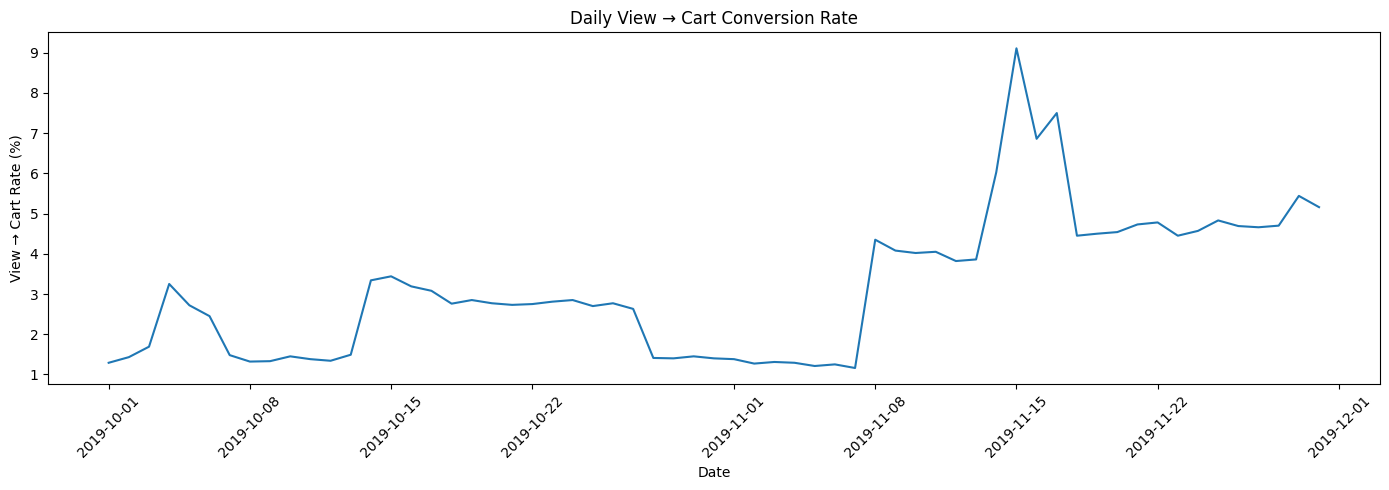

In [33]:
# 날짜별 View → Cart 전환율 변화 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(daily_funnel["event_date"], daily_funnel["view_to_cart_rate"])
plt.xlabel("Date")
plt.ylabel("View → Cart Rate (%)")
plt.title("Daily View → Cart Conversion Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

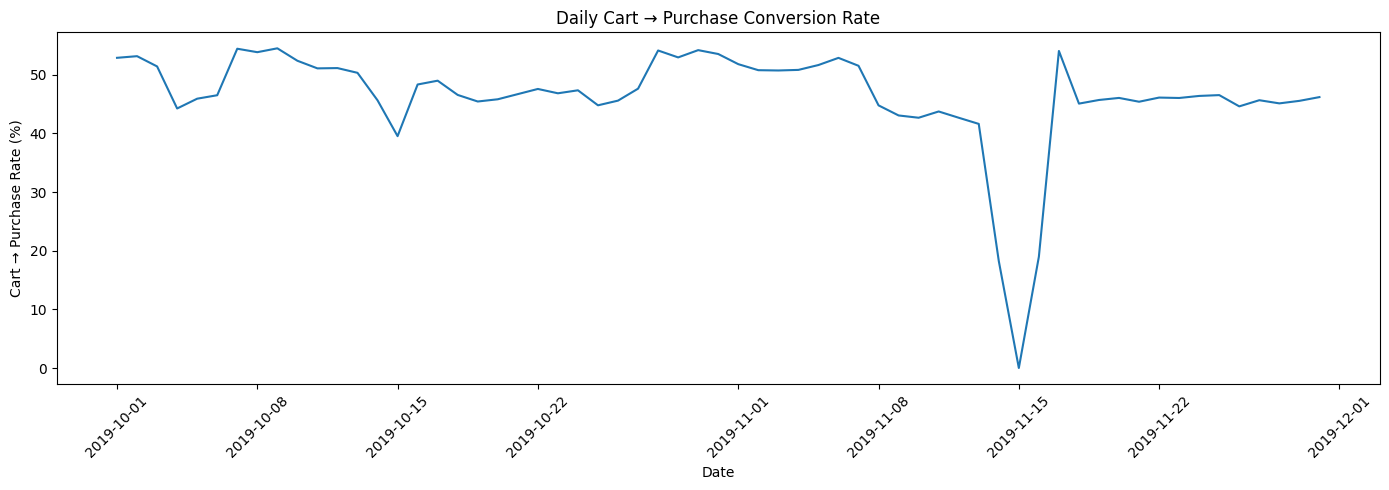

In [35]:
# 날짜별 Cart → Purchase 전환율 변화 시각화
plt.figure(figsize=(14, 5))
plt.plot(daily_funnel["event_date"], daily_funnel["cart_to_purchase_rate"])
plt.xlabel("Date")
plt.ylabel("Cart → Purchase Rate (%)")
plt.title("Daily Cart → Purchase Conversion Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

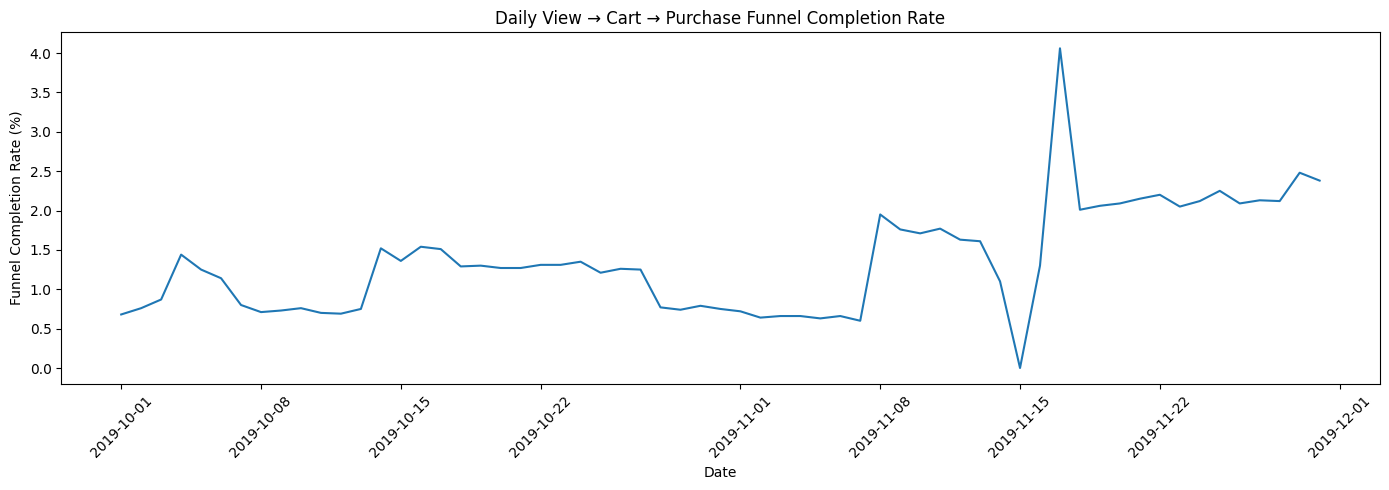

In [37]:
# 날짜별 전체 3단계 퍼널 완료율 변화 시각화
plt.figure(figsize=(14, 5))
plt.plot(daily_funnel["event_date"], daily_funnel["funnel_completion_rate"])
plt.xlabel("Date")
plt.ylabel("Funnel Completion Rate (%)")
plt.title("Daily View → Cart → Purchase Funnel Completion Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [39]:
# 확인 결과
# - 11월 중순에 View → Cart 급등, Cart → Purchase 급락이라는 비정상적 변동이 관찰됨
# - 특정 날짜의 데이터 이상 또는 서비스 환경 변화 가능성이 있으므로 추가 확인 필요
# - 이상 구간 외에도 11월 후반의 View → Cart 전환율은 10월보다 높은 수준을 유지
# - 따라서 월별 퍼널 차이가 단일 이상치만으로 발생했다고 보기는 어려움

In [41]:
# 11월 중순 이상 구간의 일별 퍼널 지표와 이벤트 규모 상세 확인
daily_funnel[
    (daily_funnel["event_date"] >= "2019-11-12") &
    (daily_funnel["event_date"] <= "2019-11-17")
]

,event_date,view_to_cart_rate,cart_to_purchase_rate,funnel_completion_rate
42,2019-11-12,3.82,42.68,1.63
43,2019-11-13,3.86,41.63,1.61
44,2019-11-14,6.03,18.24,1.10
45,2019-11-15,9.11,0.00,0.00
46,2019-11-16,6.86,18.98,1.30
47,2019-11-17,7.50,54.07,4.06


In [43]:
# 11월 중순 이상 구간에서 날짜별 view/cart/purchase 이벤트 수 확인
duckdb.sql(f"""
    SELECT
        CAST(event_time AS DATE) AS event_date,
        SUM(CASE WHEN event_type = 'view' THEN 1 ELSE 0 END) AS view_events,
        SUM(CASE WHEN event_type = 'cart' THEN 1 ELSE 0 END) AS cart_events,
        SUM(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS purchase_events
    FROM read_parquet('{parquet_path}')
    WHERE event_time >= '2019-11-12'
      AND event_time < '2019-11-18'
    GROUP BY event_date
    ORDER BY event_date
""").show()

┌────────────┬─────────────┬─────────────┬─────────────────┐
│ event_date │ view_events │ cart_events │ purchase_events │
│    date    │   int128    │   int128    │     int128      │
├────────────┼─────────────┼─────────────┼─────────────────┤
│ 2019-11-12 │     1895133 │       69711 │           22725 │
│ 2019-11-13 │     1924967 │       71650 │           22548 │
│ 2019-11-14 │     2877130 │      170472 │           22124 │
│ 2019-11-15 │     5737111 │      483305 │               0 │
│ 2019-11-16 │     6027932 │      406778 │           68247 │
│ 2019-11-17 │     5783241 │      426941 │          185195 │
└────────────┴─────────────┴─────────────┴─────────────────┘



In [45]:
# 확인 결과
# - 2019-11-15에는 view와 cart 이벤트는 대량 발생했지만 purchase 이벤트가 0건
# - 실제 구매가 전혀 없었다기보다 purchase 로그 누락 또는 데이터 수집 이상 가능성이 높음
# - 11/14~11/16 구간의 퍼널 전환율은 일반 행동 패턴 해석에 주의가 필요
# - 이상 구간을 포함한 결과와 제외한 결과를 비교해 영향도를 확인할 필요가 있음

In [47]:
# 11월 15일 시간대별 이벤트 수를 확인해 purchase 로그가 하루 전체에서 누락됐는지 검증
duckdb.sql(f"""
    SELECT
        EXTRACT('hour' FROM event_time) AS hour,
        SUM(CASE WHEN event_type = 'view' THEN 1 ELSE 0 END) AS view_events,
        SUM(CASE WHEN event_type = 'cart' THEN 1 ELSE 0 END) AS cart_events,
        SUM(CASE WHEN event_type = 'purchase' THEN 1 ELSE 0 END) AS purchase_events
    FROM read_parquet('{parquet_path}')
    WHERE event_time >= '2019-11-15'
      AND event_time < '2019-11-16'
    GROUP BY hour
    ORDER BY hour
""").show()

┌───────┬─────────────┬─────────────┬─────────────────┐
│ hour  │ view_events │ cart_events │ purchase_events │
│ int64 │   int128    │   int128    │     int128      │
├───────┼─────────────┼─────────────┼─────────────────┤
│     0 │       73315 │        6734 │               0 │
│     1 │      150961 │       13739 │               0 │
│     2 │      259630 │       22702 │               0 │
│     3 │      264031 │       27331 │               0 │
│     4 │      261919 │       28133 │               0 │
│     5 │      262766 │       27298 │               0 │
│     6 │      251698 │       26547 │               0 │
│     7 │      279119 │       28665 │               0 │
│     8 │      327605 │       31457 │               0 │
│     9 │      315388 │       29760 │               0 │
│     · │         ·   │         ·   │               · │
│     · │         ·   │         ·   │               · │
│     · │         ·   │         ·   │               · │
│    14 │      295949 │       22538 │           

In [49]:
# 확인 결과
# - 2019-11-15의 모든 시간대에서 purchase 이벤트가 0건으로 확인됨
# - view와 cart는 정상적으로 대량 발생하므로 전체 서비스 중단보다는 purchase 로그 누락 가능성이 높음
# - 해당 날짜의 Cart → Purchase 및 퍼널 완료율은 정상 행동 지표로 해석하기 어려움

In [51]:
# 11월 15일을 제외했을 때 11월 퍼널 전환율이 얼마나 달라지는지 확인
duckdb.sql(f"""
    WITH event_times AS (
        SELECT
            user_session,
            product_id,
            MIN(CASE WHEN event_type = 'view' THEN event_time END) AS first_view_time,
            MIN(CASE WHEN event_type = 'cart' THEN event_time END) AS first_cart_time,
            MIN(CASE WHEN event_type = 'purchase' THEN event_time END) AS first_purchase_time
        FROM read_parquet('{parquet_path}')
        WHERE event_time >= '2019-11-01'
          AND event_time < '2019-12-01'
          AND CAST(event_time AS DATE) <> '2019-11-15'
          AND user_session IS NOT NULL
        GROUP BY user_session, product_id
    ),
    funnel AS (
        SELECT
            SUM(CASE
                WHEN first_view_time IS NOT NULL
                THEN 1 ELSE 0
            END) AS viewed,

            SUM(CASE
                WHEN first_view_time IS NOT NULL
                 AND first_cart_time IS NOT NULL
                 AND first_view_time <= first_cart_time
                THEN 1 ELSE 0
            END) AS carted,

            SUM(CASE
                WHEN first_view_time IS NOT NULL
                 AND first_cart_time IS NOT NULL
                 AND first_purchase_time IS NOT NULL
                 AND first_view_time <= first_cart_time
                 AND first_cart_time <= first_purchase_time
                THEN 1 ELSE 0
            END) AS purchased
        FROM event_times
    )
    SELECT
        viewed,
        carted,
        purchased,
        ROUND(carted * 100.0 / viewed, 2) AS view_to_cart_rate,
        ROUND(purchased * 100.0 / carted, 2) AS cart_to_purchase_rate,
        ROUND(purchased * 100.0 / viewed, 2) AS funnel_completion_rate
    FROM funnel
""").show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌──────────┬─────────┬───────────┬───────────────────┬───────────────────────┬────────────────────────┐
│  viewed  │ carted  │ purchased │ view_to_cart_rate │ cart_to_purchase_rate │ funnel_completion_rate │
│  int128  │ int128  │  int128   │      double       │        double         │         double         │
├──────────┼─────────┼───────────┼───────────────────┼───────────────────────┼────────────────────────┤
│ 38440111 │ 1714370 │    702386 │              4.46 │                 40.97 │                   1.83 │
└──────────┴─────────┴───────────┴───────────────────┴───────────────────────┴────────────────────────┘



In [53]:
# 확인 결과
# - 11/15 purchase 로그 누락이 11월 Cart → Purchase 전환율을 크게 낮추고 있었음
# - 11/15 제외 시 Cart → Purchase는 34.53% → 40.97%로 상승
# - 하지만 10월의 47.85%보다는 여전히 낮음
# - View → Cart는 이상치 제외 후에도 10월 2.25% → 11월 4.46%로 크게 증가
# - 따라서 11월의 퍼널 구조 변화는 이상치 하나만으로 설명되지 않음

In [55]:
# 10월과 11월(11/15 제외)의 퍼널 지표를 최종 비교
duckdb.sql(f"""
    WITH event_times AS (
        SELECT
            CASE
                WHEN event_time >= '2019-10-01' AND event_time < '2019-11-01'
                    THEN '2019-10'
                WHEN event_time >= '2019-11-01' AND event_time < '2019-12-01'
                     AND CAST(event_time AS DATE) <> '2019-11-15'
                    THEN '2019-11'
            END AS month_group,
            user_session,
            product_id,
            MIN(CASE WHEN event_type = 'view' THEN event_time END) AS first_view_time,
            MIN(CASE WHEN event_type = 'cart' THEN event_time END) AS first_cart_time,
            MIN(CASE WHEN event_type = 'purchase' THEN event_time END) AS first_purchase_time
        FROM read_parquet('{parquet_path}')
        WHERE user_session IS NOT NULL
          AND (
                (event_time >= '2019-10-01' AND event_time < '2019-11-01')
             OR (event_time >= '2019-11-01' AND event_time < '2019-12-01'
                 AND CAST(event_time AS DATE) <> '2019-11-15')
          )
        GROUP BY month_group, user_session, product_id
    ),
    funnel AS (
        SELECT
            month_group,

            SUM(CASE
                WHEN first_view_time IS NOT NULL
                THEN 1 ELSE 0
            END) AS viewed,

            SUM(CASE
                WHEN first_view_time IS NOT NULL
                 AND first_cart_time IS NOT NULL
                 AND first_view_time <= first_cart_time
                THEN 1 ELSE 0
            END) AS carted,

            SUM(CASE
                WHEN first_view_time IS NOT NULL
                 AND first_cart_time IS NOT NULL
                 AND first_purchase_time IS NOT NULL
                 AND first_view_time <= first_cart_time
                 AND first_cart_time <= first_purchase_time
                THEN 1 ELSE 0
            END) AS purchased

        FROM event_times
        GROUP BY month_group
    )
    SELECT
        month_group,
        viewed,
        carted,
        purchased,
        ROUND(carted * 100.0 / viewed, 2) AS view_to_cart_rate,
        ROUND(purchased * 100.0 / carted, 2) AS cart_to_purchase_rate,
        ROUND(purchased * 100.0 / viewed, 2) AS funnel_completion_rate
    FROM funnel
    ORDER BY month_group
""").show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────┬──────────┬─────────┬───────────┬───────────────────┬───────────────────────┬────────────────────────┐
│ month_group │  viewed  │ carted  │ purchased │ view_to_cart_rate │ cart_to_purchase_rate │ funnel_completion_rate │
│   varchar   │  int128  │ int128  │  int128   │      double       │        double         │         double         │
├─────────────┼──────────┼─────────┼───────────┼───────────────────┼───────────────────────┼────────────────────────┤
│ 2019-10     │ 27783702 │  625400 │    299235 │              2.25 │                 47.85 │                   1.08 │
│ 2019-11     │ 38440111 │ 1714370 │    702386 │              4.46 │                 40.97 │                   1.83 │
└─────────────┴──────────┴─────────┴───────────┴───────────────────┴───────────────────────┴────────────────────────┘



In [1]:
# 최종 해석
# - 11월은 11/15 purchase 로그 누락일을 제외해 비교
# - 11월의 View → Cart 전환율은 10월보다 높음
# - 11월의 Cart → Purchase 전환율은 10월보다 낮음
# - 최종 퍼널 완료율은 11월이 더 높음
# - 따라서 11월은 장바구니 진입은 증가했지만, 장바구니 이후 구매 효율은 상대적으로 낮아진 구조
# - 원인은 퍼널 데이터만으로 단정하지 않고 이후 장바구니 이탈 분석에서 추가 검증

In [ ]:
#---------------------------------------------------------------------------------------------------------------------------#

In [7]:
# Tableau용 월별 퍼널 집계 데이터를 CSV로 저장
monthly_funnel = duckdb.sql(f"""
    WITH event_times AS (
        SELECT
            CASE
                WHEN event_time >= '2019-10-01' AND event_time < '2019-11-01'
                    THEN '2019-10'
                WHEN event_time >= '2019-11-01' AND event_time < '2019-12-01'
                     AND CAST(event_time AS DATE) <> '2019-11-15'
                    THEN '2019-11'
            END AS month,
            user_session,
            product_id,
            MIN(CASE WHEN event_type = 'view' THEN event_time END) AS first_view_time,
            MIN(CASE WHEN event_type = 'cart' THEN event_time END) AS first_cart_time,
            MIN(CASE WHEN event_type = 'purchase' THEN event_time END) AS first_purchase_time

        FROM read_parquet('{parquet_path}')

        WHERE user_session IS NOT NULL
          AND (
                (event_time >= '2019-10-01' AND event_time < '2019-11-01')
             OR (event_time >= '2019-11-01' AND event_time < '2019-12-01'
                 AND CAST(event_time AS DATE) <> '2019-11-15')
          )

        GROUP BY month, user_session, product_id
    ),

    funnel AS (
        SELECT
            month,

            SUM(CASE
                WHEN first_view_time IS NOT NULL
                THEN 1 ELSE 0
            END) AS viewed,

            SUM(CASE
                WHEN first_view_time IS NOT NULL
                 AND first_cart_time IS NOT NULL
                 AND first_view_time <= first_cart_time
                THEN 1 ELSE 0
            END) AS carted,

            SUM(CASE
                WHEN first_view_time IS NOT NULL
                 AND first_cart_time IS NOT NULL
                 AND first_purchase_time IS NOT NULL
                 AND first_view_time <= first_cart_time
                 AND first_cart_time <= first_purchase_time
                THEN 1 ELSE 0
            END) AS purchased

        FROM event_times
        GROUP BY month
    )

    SELECT
        month,
        viewed,
        carted,
        purchased,
        ROUND(carted * 100.0 / viewed, 2) AS view_to_cart_rate,
        ROUND(purchased * 100.0 / carted, 2) AS cart_to_purchase_rate,
        ROUND(purchased * 100.0 / viewed, 2) AS funnel_completion_rate

    FROM funnel
    ORDER BY month
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [8]:
# 월별 퍼널 데이터를 Tableau용 CSV로 저장
monthly_funnel.to_csv(
    r"..\data\marts\dashboard_funnel.csv",
    index=False
)

In [9]:
# 저장된 Tableau용 퍼널 데이터 확인
monthly_funnel

,month,viewed,carted,purchased,view_to_cart_rate,cart_to_purchase_rate,funnel_completion_rate
0,2019-10,27783702.0,625400.0,299235.0,2.25,47.85,1.08
1,2019-11,38440111.0,1714370.0,702386.0,4.46,40.97,1.83


In [14]:
# Tableau용 일별 퍼널 전환율 데이터를 생성
daily_funnel = duckdb.sql(f"""
    WITH event_times AS (
        SELECT
            CAST(event_time AS DATE) AS event_date,
            user_session,
            product_id,

            MIN(CASE WHEN event_type = 'view'
                THEN event_time END) AS first_view_time,

            MIN(CASE WHEN event_type = 'cart'
                THEN event_time END) AS first_cart_time,

            MIN(CASE WHEN event_type = 'purchase'
                THEN event_time END) AS first_purchase_time

        FROM read_parquet('{parquet_path}')

        WHERE user_session IS NOT NULL
          AND CAST(event_time AS DATE) <> '2019-11-15'

        GROUP BY event_date, user_session, product_id
    ),

    funnel AS (
        SELECT
            event_date,

            SUM(CASE
                WHEN first_view_time IS NOT NULL
                THEN 1 ELSE 0
            END) AS viewed,

            SUM(CASE
                WHEN first_view_time IS NOT NULL
                 AND first_cart_time IS NOT NULL
                 AND first_view_time <= first_cart_time
                THEN 1 ELSE 0
            END) AS carted,

            SUM(CASE
                WHEN first_view_time IS NOT NULL
                 AND first_cart_time IS NOT NULL
                 AND first_purchase_time IS NOT NULL
                 AND first_view_time <= first_cart_time
                 AND first_cart_time <= first_purchase_time
                THEN 1 ELSE 0
            END) AS purchased

        FROM event_times
        GROUP BY event_date
    )

    SELECT
        event_date,
        viewed,
        carted,
        purchased,
        ROUND(carted * 100.0 / viewed, 2) AS view_to_cart_rate,
        ROUND(purchased * 100.0 / carted, 2) AS cart_to_purchase_rate,
        ROUND(purchased * 100.0 / viewed, 2) AS funnel_completion_rate

    FROM funnel
    ORDER BY event_date
""").df()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [15]:
# 일별 퍼널 데이터를 Tableau용 CSV로 저장
daily_funnel.to_csv(
    r"..\data\marts\dashboard_daily_funnel.csv",
    index=False
)

In [16]:
# 저장할 일별 퍼널 데이터 일부 확인
daily_funnel.head()

,event_date,viewed,carted,purchased,view_to_cart_rate,cart_to_purchase_rate,funnel_completion_rate
0,2019-10-01,836603.0,10818.0,5723.0,1.29,52.90,0.68
1,2019-10-02,792947.0,11321.0,6020.0,1.43,53.18,0.76
2,2019-10-03,740287.0,12509.0,6433.0,1.69,51.43,0.87
3,2019-10-04,907204.0,29503.0,13057.0,3.25,44.26,1.44
4,2019-10-05,857846.0,23362.0,10731.0,2.72,45.93,1.25
